# Boundary Conditions and Convergence

## Author: Zach Etienne

This notebook adapts the active Cartesian wave project generator authored by
Zach Etienne and uses the same scalar-wave boundary and diagnostic ideas as
the legacy NRPy wave tutorials.

To run the whole notebook, click the `>>` toolbar button and choose
**Restart Kernel and Run All Cells...**.

This notebook generates a Cartesian scalar-wave project, inspects the
generated boundary-condition source, builds and runs two resolutions, and
validates the pointwise center-error convergence.

**Notebook Status:** Validated

**Validation Notes:** The final validation section checks generated
boundary-source terms, confirms four RK-stage boundary calls, and requires
the refined pointwise `uu` error to beat the conservative fourth-order
threshold.

Navigation: [Index](../index.ipynb) |
Previous: [Method of Lines and Runge-Kutta](method_of_lines_and_rk.ipynb) |
Next: [Finite-Difference Playground](finite_difference_playground.ipynb)

# Table of Contents

1. [Required Reading and Source Links](#Required-Reading-and-Source-Links)
1. [Words for This Notebook](#Words-for-This-Notebook)
1. [Step 1](#Step-1:-State-the-Boundary-Test-Initial-Value-Problem): State the IVP.
1. [Workspace and Generated Files](#Workspace-and-Generated-Files): Define owned output.
1. [Step 2](#Step-2:-Generate-the-Boundary-Test-Project): Generate the project.
1. [Step 3](#Step-3:-Inspect-Generated-Files): Inspect generated files.
1. [Step 4](#Step-4:-Shorten-the-Runtime-Parameter-File): Shorten the run.
1. [Step 5](#Step-5:-Build-the-Boundary-Test-Executable): Build.
1. [Step 6](#Step-6:-Run-the-Coarse-Boundary-Test): Run coarse grid.
1. [Step 7](#Step-7:-Run-the-Refined-Boundary-Test): Run refined grid.
1. [Step 8](#Step-8:-Load-Diagnostic-Rows): Load diagnostics.
1. [Step 9](#Step-9:-Plot-Boundary-Test-Error-Histories): Plot histories.
1. [Validation Check](#Validation-Check): Validate generated source and convergence.
1. [What next?](#What-next?)

# Required Reading and Source Links
### [Back to [top](#Table-of-Contents)]

Required reading:

- [Wave Equation with NumPy](wave_equation_with_numpy.ipynb): defines the
  scalar wave initial-value problem and boundary update algorithm.
- [Method of Lines and Runge-Kutta](method_of_lines_and_rk.ipynb): explains
  the RK4 stage schedule inspected in the generated project.

Installed source modules used by this lesson:

- `nrpy.examples.wave_equation_cartesian`: writes the project built and run
  here.
- `nrpy.equations.wave_equation.WaveEquation_RHSs`: symbolic right-hand side
  used by generated C.
- `nrpy.equations.wave_equation.WaveEquation_Solutions_InitialData`: exact
  solution used by diagnostics.
- `nrpy.infrastructures.BHaH.MoLtimestepping.MoL_step_forward_in_time`:
  generated RK driver source.
- Legacy scalar-wave tutorial lineage: provenance for the wave model and
  quadratic-extrapolation boundary algorithm.

# Words for This Notebook
### [Back to [top](#Table-of-Contents)]

- **Workspace:** The notebook-owned directory where generated files, logs,
  diagnostics, and build products are written.
- **Project directory:** The generated C project directory inside the
  workspace.
- **Generated artifact:** A file written by NRPy and inspected or used later.
- **Parameter file:** Runtime settings read by the generated executable.
- **Build:** Compiling generated C source into an executable.
- **Run:** Executing the generated program.
- **Boundary condition:** A rule for values at grid boundaries.
- **Ghost zone:** Extra grid cells outside the physical domain that support
  centered finite-difference stencils near boundaries.
- **Quadratic extrapolation:** Filling a ghost point with `3u_1 - 3u_2 + u_3`
  from inward neighboring points.
- **Diagnostic row:** One line of runtime output data used for validation.
- **Convergence factor:** The multiplier applied to the default resolution.
- **Pointwise relative error:** Center-point `abs((uu_numeric - uu_exact) / uu_exact)`;
  this is a pointwise diagnostic, not a norm.

# Step 1: State the Boundary-Test Initial-Value Problem
### [Back to [top](#Table-of-Contents)]

The generated project solves the Cartesian scalar wave equation

$$
\partial_t^2 u = c^2 \nabla^2 u
$$

on a cell-centered Cartesian cube. The evolved variables are `uu`, the wave
amplitude `u`, and `vv = partial_t uu`. The tutorial uses dimensionless units
and the generated parameter `wavespeed = 1`.

The project initializes a spherical-Gaussian exact solution, advances it with
fourth-order spatial finite differences and RK4 Method-of-Lines time
stepping, fills outer ghost zones by quadratic extrapolation, and writes
pointwise center diagnostics. Smooth fourth-order refinement should reduce
the center `uu` error by about `2^4 = 16` when the grid spacing is halved.
The validation uses a conservative threshold of `12`.

# Workspace and Generated Files
### [Back to [top](#Table-of-Contents)]

This notebook owns the stable workspace
`project/boundary_conditions_and_convergence` under the notebook directory.
Each run cleans and recreates only that workspace before project generation.
It does not delete any other project directory.

Generated project output is written under
`project/boundary_conditions_and_convergence/project/wave_equation_cartesian`.

Key generated artifacts:

| Artifact | Role | Where used | What to inspect |
| --- | --- | --- | --- |
| `Makefile` | Build script | Build step | compiler command targets |
| `apply_bcs.c` | Boundary source | Source/validation | `FACE_UPDATE`, `NGHOSTS` |
| `MoL/MoL_step_forward_in_time.c` | RK4 driver | Source/validation | four BC calls |
| `diagnostics.c` | Center-error diagnostics | Runtime evidence | output file and columns |
| `wave_equation_cartesian.par` | Runtime settings | Run setup | `t_final`, output cadence |
| `BHaH_defines.h` | Infrastructure definitions | Build | `NGHOSTS`, grid macros |
| `BHaH_function_prototypes.h` | Function prototypes | Build | generated function declarations |
| `set_CodeParameters.h` | Runtime parameter unpacking | Generated C | parameter names |

This helper cell is practical setup. It manages the owned workspace, runs
commands, writes complete logs, and prints sanitized paths relative to the
notebook directory.

In [1]:
from pathlib import Path
import importlib.util
import logging
import re
import shutil
import subprocess
import sys

import numpy as np


NOTEBOOK_DIR = Path.cwd().resolve()
FORBIDDEN_SOURCE_ROOTS = [NOTEBOOK_DIR.parent / "nrpy"]
logging.getLogger("matplotlib").setLevel(logging.WARNING)
PROJECT_NAME = "wave_equation_cartesian"
WORKSPACE = Path("project") / "boundary_conditions_and_convergence"
PROJECT_DIR = WORKSPACE / "project" / PROJECT_NAME


def installed_source_path(module_name):
    spec = importlib.util.find_spec(module_name)
    if spec is None or spec.origin is None:
        raise RuntimeError(f"Could not locate installed module: {module_name}")
    path = Path(spec.origin).resolve()
    for root in FORBIDDEN_SOURCE_ROOTS:
        if not root.exists():
            continue
        try:
            path.relative_to(root.resolve())
        except ValueError:
            continue
        raise RuntimeError(f"{module_name} resolved to cloned source: {path}")
    return path


def display_path(path):
    resolved = Path(path).resolve()
    try:
        return str(resolved.relative_to(NOTEBOOK_DIR))
    except ValueError:
        return str(resolved)


def clean_command_output(text):
    cleaned = re.sub(r"\x1b\[[0-?]*[ -/]*[@-~]", "", text or "")
    return cleaned.replace(str(NOTEBOOK_DIR), "<notebook_dir>")


def run_command(args, cwd, timeout, log_path):
    try:
        result = subprocess.run(
            args,
            cwd=cwd,
            text=True,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            check=True,
            timeout=timeout,
        )
    except FileNotFoundError as exc:
        raise RuntimeError(f"Required command is missing: {args[0]}") from exc
    except subprocess.CalledProcessError as exc:
        output = clean_command_output(exc.stdout)
        log_path.write_text(output, encoding="utf-8")
        print(output)
        raise RuntimeError(f"Command failed: {' '.join(map(str, args))}") from exc

    output = clean_command_output(result.stdout)
    log_path.write_text(output, encoding="utf-8")
    return output


def require_toolchain():
    if shutil.which("make") is None:
        raise RuntimeError("This notebook requires make.")
    if not any(shutil.which(name) for name in ["cc", "gcc", "clang"]):
        raise RuntimeError("This notebook requires a C compiler.")


def print_log_summary(label, log_path, complete_if_at_most=80):
    text = log_path.read_text(encoding="utf-8", errors="replace")
    lines = text.splitlines()
    warning_lines = [line for line in lines if "warning" in line.lower()]
    error_lines = [line for line in lines if "error" in line.lower()]
    print(label, "log path:", display_path(log_path))
    print(label, "line count:", len(lines))
    print(label, "warning count:", len(warning_lines))
    print(label, "error count:", len(error_lines))
    if len(lines) <= complete_if_at_most:
        print(f"--- complete {label} log ---")
        print(text.rstrip())
    else:
        print(f"--- {label} warning/error summary ---")
        for line in warning_lines + error_lines:
            print(line)


def classify_file(path):
    suffix = path.suffix
    if suffix == ".c":
        return "source"
    if suffix == ".h":
        return "header"
    if suffix in {".par", ".txt"}:
        return "parameter/config"
    if path.name == "Makefile":
        return "build script"
    return "other"


print("workspace policy: clean and recreate owned workspace")
print("workspace:", display_path(WORKSPACE))
print("project path:", display_path(PROJECT_DIR))
source_modules = [
    "nrpy.equations.wave_equation.WaveEquation_RHSs",
    "nrpy.equations.wave_equation.WaveEquation_Solutions_InitialData",
    "nrpy.examples.wave_equation_cartesian",
    "nrpy.infrastructures.BHaH.MoLtimestepping.MoL_step_forward_in_time",
]
print("installed NRPy source paths:")
for module_name in source_modules:
    print(module_name, "->", installed_source_path(module_name))

workspace policy: clean and recreate owned workspace
workspace: project/boundary_conditions_and_convergence
project path: project/boundary_conditions_and_convergence/project/wave_equation_cartesian
installed NRPy source paths:
nrpy.equations.wave_equation.WaveEquation_RHSs -> /virt/lib/python3.12/site-packages/nrpy/equations/wave_equation/WaveEquation_RHSs.py
nrpy.equations.wave_equation.WaveEquation_Solutions_InitialData -> /virt/lib/python3.12/site-packages/nrpy/equations/wave_equation/WaveEquation_Solutions_InitialData.py
nrpy.examples.wave_equation_cartesian -> /virt/lib/python3.12/site-packages/nrpy/examples/wave_equation_cartesian.py


nrpy.infrastructures.BHaH.MoLtimestepping.MoL_step_forward_in_time -> /virt/lib/python3.12/site-packages/nrpy/infrastructures/BHaH/MoLtimestepping/MoL_step_forward_in_time.py


# Step 2: Generate the Boundary-Test Project
### [Back to [top](#Table-of-Contents)]

The command below invokes the same generator a learner can run from a
terminal. The notebook cleans only its owned workspace before running it.

In [2]:
if WORKSPACE.exists():
    shutil.rmtree(WORKSPACE)
WORKSPACE.mkdir(parents=True)

command = [sys.executable, "-m", "nrpy.examples.wave_equation_cartesian"]
generator_log = WORKSPACE / "generator.log"
print("generator command: python -m nrpy.examples.wave_equation_cartesian")
generator_output = run_command(command, WORKSPACE, timeout=300, log_path=generator_log)
print_log_summary("generator", generator_log)
if not PROJECT_DIR.is_dir():
    raise FileNotFoundError(PROJECT_DIR)
print("project path:", display_path(PROJECT_DIR))

generator command: python -m nrpy.examples.wave_equation_cartesian


generator log path: project/boundary_conditions_and_convergence/generator.log
generator line count: 2
generator warning count: 0
generator error count: 0
--- complete generator log ---
Finished! Now go into project/wave_equation_cartesian and type `make` to build, then ./wave_equation_cartesian to run.
    Parameter file can be found in wave_equation_cartesian.par
project path: project/boundary_conditions_and_convergence/project/wave_equation_cartesian


# Step 3: Inspect Generated Files
### [Back to [top](#Table-of-Contents)]

The inventory below lists every regular file generated before build. It is
complete for the generated source/config project state. After build and run,
a second inventory lists logs and diagnostics created by this notebook.

In [3]:
generated_inventory = sorted(
    path
    for path in PROJECT_DIR.rglob("*")
    if path.is_file()
)
print("complete generated source/config inventory:")
print("artifact | kind")
for path in generated_inventory:
    relative_path = path.relative_to(PROJECT_DIR)
    print(relative_path, "|", classify_file(path))

expected_key_files = [
    "Makefile",
    "apply_bcs.c",
    "MoL/MoL_step_forward_in_time.c",
    "diagnostics.c",
    "wave_equation_cartesian.par",
    "BHaH_defines.h",
    "BHaH_function_prototypes.h",
    "set_CodeParameters.h",
]
missing_key_files = [
    relative_path
    for relative_path in expected_key_files
    if not (PROJECT_DIR / relative_path).is_file()
]
if missing_key_files:
    raise FileNotFoundError(f"Missing generated files: {missing_key_files}")

complete generated source/config inventory:
artifact | kind
BHaH_defines.h | header
BHaH_function_prototypes.h | header
Makefile | build script
MoL/MoL_free_intermediate_stage_gfs.c | source
MoL/MoL_malloc_intermediate_stage_gfs.c | source
MoL/MoL_step_forward_in_time.c | source
apply_bcs.c | source
cmdline_input_and_parfile_parser.c | source
commondata_struct_set_to_default.c | source
diagnostics.c | source
exact_solution_single_Cartesian_point.c | source
griddata_free.c | source
initial_data.c | source
intrinsics/simd_intrinsics.h | header
main.c | source
numerical_grids_and_timestep.c | source
params_struct_set_to_default.c | source
progress_indicator.c | source
rhs_eval.c | source
set_CodeParameters-nopointer.h | header
set_CodeParameters-simd.h | header
set_CodeParameters.h | header
wave_equation_cartesian.par | parameter/config


The complete `apply_bcs.c` file is the required boundary-source artifact.
Inspect the `FACE_UPDATE` macro, the ghost-zone loop, and the coefficients
`+3.0`, `-3.0`, and `+1.0`.

In [4]:
apply_bcs_path = PROJECT_DIR / "apply_bcs.c"
apply_bcs_text = apply_bcs_path.read_text(encoding="utf-8", errors="replace")
print("--- complete apply_bcs.c ---")
print(apply_bcs_text)

--- complete apply_bcs.c ---
#include "BHaH_defines.h"

// Declare boundary condition FACE_UPDATE macro,
//          which updates a single face of the 3D grid cube
//          using quadratic polynomial extrapolation.
const int MAXFACE = -1;
const int NUL = +0;
const int MINFACE = +1;
#define FACE_UPDATE(which_gf, i0min, i0max, i1min, i1max, i2min, i2max, FACEX0, FACEX1, FACEX2)                                                      \
  for (int i2 = i2min; i2 < i2max; i2++)                                                                                                             \
    for (int i1 = i1min; i1 < i1max; i1++)                                                                                                           \
      for (int i0 = i0min; i0 < i0max; i0++) {                                                                                                       \
        gfs[IDX4(which_gf, i0, i1, i2)] = +3.0 * gfs[IDX4(which_gf, i0 + 1 * FACEX0, i1 + 1 * FACEX1, i2 + 1 

The complete boundary-call inventory below is parsed from the generated RK4
driver. It should contain one `apply_bcs` call after each RK stage.

In [5]:
mol_step_path = PROJECT_DIR / "MoL" / "MoL_step_forward_in_time.c"
mol_step_text = mol_step_path.read_text(encoding="utf-8", errors="replace")
apply_bcs_call_lines = [
    line.strip()
    for line in mol_step_text.splitlines()
    if "apply_bcs(" in line and not line.strip().startswith("*")
]
print("complete boundary-condition call inventory:")
for index, line in enumerate(apply_bcs_call_lines, start=1):
    print(index, line)

complete boundary-condition call inventory:
1 apply_bcs(commondata, params, k_odd_gfs);
2 apply_bcs(commondata, params, k_even_gfs);
3 apply_bcs(commondata, params, k_odd_gfs);
4 apply_bcs(commondata, params, y_n_gfs);


# Step 4: Shorten the Runtime Parameter File
### [Back to [top](#Table-of-Contents)]

Only runtime parameters are changed. The full parameter file is printed so
`t_final`, `diagnostics_output_every`, and `output_progress_every` are visible.

In [6]:
parfile = PROJECT_DIR / "wave_equation_cartesian.par"
par_text = parfile.read_text(encoding="utf-8")
par_text = par_text.replace("t_final = 8.0", "t_final = 0.3125")
par_text = par_text.replace(
    "diagnostics_output_every = 0.2",
    "diagnostics_output_every = 0.15625",
)
par_text = par_text.replace(
    "output_progress_every = 1",
    "output_progress_every = 1000000",
)
parfile.write_text(par_text, encoding="utf-8")
print("--- complete runtime wave_equation_cartesian.par ---")
print(parfile.read_text(encoding="utf-8", errors="replace"))

--- complete runtime wave_equation_cartesian.par ---
#### wave_equation_cartesian BH@H parameter file. NOTE: only commondata CodeParameters appear here ###
###########################
###########################
### Module: __main__
convergence_factor = 1.0        # (REAL)
diagnostics_output_every = 0.15625  # (REAL)
###########################
###########################
### Module: nrpy.equations.wave_equation.WaveEquation_Solutions_InitialData
sigma = 3.0                     # (REAL)
wavespeed = 1.0                 # (REAL)
###########################
###########################
### Module: nrpy.infrastructures.BHaH.MoLtimestepping.register_all
CFL_FACTOR = 0.5                # (REAL)
t_final = 0.3125                   # (REAL)
###########################
###########################
### Module: nrpy.infrastructures.BHaH.diagnostics.progress_indicator
output_progress_every = 1000000       # (int)



# Step 5: Build the Boundary-Test Executable
### [Back to [top](#Table-of-Contents)]

The build command compiles generated C source. The complete combined
stdout/stderr stream is saved to `build.log` and printed when short.

In [7]:
require_toolchain()
build_log = WORKSPACE / "build.log"
print("build command: make -j2")
_ = run_command(["make", "-j2"], PROJECT_DIR, timeout=300, log_path=build_log)
if not build_log.is_file() or build_log.stat().st_size == 0:
    raise RuntimeError("Expected nonempty build.log.")
print_log_summary("build", build_log)
print("build status: PASS")

build command: make -j2


build log path: project/boundary_conditions_and_convergence/build.log
build line count: 16
build warning count: 0
build error count: 0
--- complete build log ---
cc -std=gnu99 -O2 -march=native -g -Wall -I. -fopenmp  -c apply_bcs.c -o apply_bcs.o
cc -std=gnu99 -O2 -march=native -g -Wall -I. -fopenmp  -c cmdline_input_and_parfile_parser.c -o cmdline_input_and_parfile_parser.o
cc -std=gnu99 -O2 -march=native -g -Wall -I. -fopenmp  -c commondata_struct_set_to_default.c -o commondata_struct_set_to_default.o
cc -std=gnu99 -O2 -march=native -g -Wall -I. -fopenmp  -c diagnostics.c -o diagnostics.o
cc -std=gnu99 -O2 -march=native -g -Wall -I. -fopenmp  -c exact_solution_single_Cartesian_point.c -o exact_solution_single_Cartesian_point.o
cc -std=gnu99 -O2 -march=native -g -Wall -I. -fopenmp  -c griddata_free.c -o griddata_free.o
cc -std=gnu99 -O2 -march=native -g -Wall -I. -fopenmp  -c initial_data.c -o initial_data.o
cc -std=gnu99 -O2 -march=native -g -Wall -I. -fopenmp  -c main.c -o main.o
cc

# Step 6: Run the Coarse Boundary Test
### [Back to [top](#Table-of-Contents)]

The default run uses convergence factor `1.0`. Its complete combined
stdout/stderr stream is saved to `coarse_run.log`.

In [8]:
coarse_log = WORKSPACE / "coarse_run.log"
print("coarse run command: ./wave_equation_cartesian")
_ = run_command([f"./{PROJECT_NAME}"], PROJECT_DIR, timeout=90, log_path=coarse_log)
if not coarse_log.is_file() or coarse_log.stat().st_size == 0:
    raise RuntimeError("Expected nonempty coarse_run.log.")
print_log_summary("coarse run", coarse_log)
print("coarse run status: PASS")

coarse run command: ./wave_equation_cartesian
coarse run log path: project/boundary_conditions_and_convergence/coarse_run.log
coarse run line count: 1
coarse run warning count: 0
coarse run error count: 0
--- complete coarse run log ---
It: 0 t=0.000 / 0.3 = 0.00% dt=1/6.4 | t/h=0.00 ETA 0h00m00s
coarse run status: PASS


# Step 7: Run the Refined Boundary Test
### [Back to [top](#Table-of-Contents)]

The refined run passes convergence factor `2.0`, halving the grid spacing in
each coordinate direction.

In [9]:
refined_log = WORKSPACE / "refined_run.log"
print("refined run command: ./wave_equation_cartesian 2.0")
_ = run_command([f"./{PROJECT_NAME}", "2.0"], PROJECT_DIR, timeout=90, log_path=refined_log)
if not refined_log.is_file() or refined_log.stat().st_size == 0:
    raise RuntimeError("Expected nonempty refined_run.log.")
print_log_summary("refined run", refined_log)
print("refined run status: PASS")

refined run command: ./wave_equation_cartesian 2.0


refined run log path: project/boundary_conditions_and_convergence/refined_run.log
refined run line count: 1
refined run warning count: 0
refined run error count: 0
--- complete refined run log ---
It: 0 t=0.000 / 0.3 = 0.00% dt=1/12.8 | t/h=0.00 ETA 0h00m00s
refined run status: PASS


# Step 8: Load Diagnostic Rows
### [Back to [top](#Table-of-Contents)]

The diagnostic files provide the runtime numerical evidence. Each nonblank
row has this schema:

| Column | Name | Meaning |
| --- | --- | --- |
| 0 | `time` | Physical simulation time |
| 1 | `uu_relative_error` | Pointwise relative error in `uu` at the grid center |
| 2 | `vv_relative_error` | Pointwise relative error in `vv` at the grid center |
| 3 | `uu_numeric_center` | Numerical `uu` value at the grid center |
| 4 | `uu_exact_center` | Exact `uu` value at the grid center |

In [10]:
TIME_COL = 0
UU_REL_ERROR_COL = 1
VV_REL_ERROR_COL = 2
UU_NUMERIC_COL = 3
UU_EXACT_COL = 4
DIAGNOSTIC_COLUMNS = {
    TIME_COL: "time",
    UU_REL_ERROR_COL: "uu_relative_error",
    VV_REL_ERROR_COL: "vv_relative_error",
    UU_NUMERIC_COL: "uu_numeric_center",
    UU_EXACT_COL: "uu_exact_center",
}
print("diagnostic columns:")
for index, name in DIAGNOSTIC_COLUMNS.items():
    print(index, name)

diagnostic_rows = {}
for diagnostic in sorted(PROJECT_DIR.glob("out0d-conv_factor*.txt")):
    rows = []
    for line_number, line in enumerate(
        diagnostic.read_text(encoding="utf-8", errors="replace").splitlines(),
        start=1,
    ):
        if not line.strip():
            continue
        values = [float(value) for value in line.split()]
        if len(values) != len(DIAGNOSTIC_COLUMNS):
            raise RuntimeError(
                f"{diagnostic.name}:{line_number} has {len(values)} columns."
            )
        rows.append(values)
    diagnostic_rows[diagnostic.name] = rows
    times = [row[TIME_COL] for row in rows]
    last_row = rows[-1]
    print("diagnostic file:", diagnostic.name)
    print("row count:", len(rows))
    print("output times:", ", ".join(f"{time:.6e}" for time in times))
    print("final uu relative error:", f"{last_row[UU_REL_ERROR_COL]:.6e}")
    print("final vv relative error:", f"{last_row[VV_REL_ERROR_COL]:.6e}")

artifact_inventory = [
    generator_log,
    build_log,
    coarse_log,
    refined_log,
    *sorted(PROJECT_DIR.glob("out0d-conv_factor*.txt")),
]
print("learner-created logs and diagnostics:")
for path in artifact_inventory:
    print(display_path(path))

diagnostic columns:
0 time
1 uu_relative_error
2 vv_relative_error
3 uu_numeric_center
4 uu_exact_center
diagnostic file: out0d-conv_factor1.00.txt
row count: 2
output times: 0.000000e+00, 1.562500e-01
final uu relative error: 4.061498e-08
final vv relative error: 2.140944e-05
diagnostic file: out0d-conv_factor2.00.txt
row count: 2
output times: 0.000000e+00, 1.562500e-01
final uu relative error: 2.797348e-09
final vv relative error: 1.349218e-06
learner-created logs and diagnostics:
project/boundary_conditions_and_convergence/generator.log
project/boundary_conditions_and_convergence/build.log
project/boundary_conditions_and_convergence/coarse_run.log
project/boundary_conditions_and_convergence/refined_run.log
project/boundary_conditions_and_convergence/project/wave_equation_cartesian/out0d-conv_factor1.00.txt
project/boundary_conditions_and_convergence/project/wave_equation_cartesian/out0d-conv_factor2.00.txt


# Step 9: Plot Boundary-Test Error Histories
### [Back to [top](#Table-of-Contents)]

The plot shows the full positive-error history on a log scale. The refined
curve should stay below the coarse curve at matching physical output times.

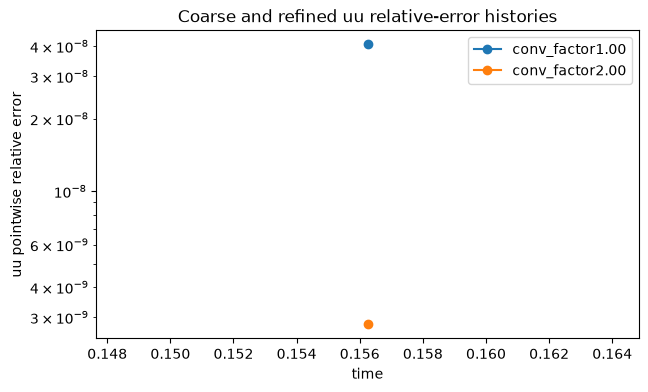

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
for name, rows in sorted(diagnostic_rows.items()):
    positive_rows = [row for row in rows if row[UU_REL_ERROR_COL] > 0.0]
    times = [row[TIME_COL] for row in positive_rows]
    errors = [row[UU_REL_ERROR_COL] for row in positive_rows]
    label = name.replace("out0d-", "").replace(".txt", "")
    plt.plot(times, errors, marker="o", label=label)

plt.yscale("log")
plt.xlabel("time")
plt.ylabel("uu pointwise relative error")
plt.title("Coarse and refined uu relative-error histories")
plt.legend()
plt.show()

# Validation Check
### [Back to [top](#Table-of-Contents)]

This validation combines generated-source evidence with runtime diagnostic
evidence. The source checks prove that generated C fills ghost zones by
quadratic extrapolation and applies boundary conditions at all four RK stages.
The runtime check compares pointwise center `uu` errors at the same physical
time. A smooth fourth-order method should reduce the error by about `16`;
this notebook requires the conservative threshold `error_ratio > 12`.

In [12]:
required_boundary_terms = [
    "quadratic polynomial extrapolation",
    "FACE_UPDATE",
    "NGHOSTS",
    "+3.0",
    "1.0 *",
]
missing_boundary_terms = [
    term for term in required_boundary_terms if term not in apply_bcs_text
]
if missing_boundary_terms:
    raise RuntimeError(f"Missing boundary-source terms: {missing_boundary_terms}")
if apply_bcs_text.count("3.0 *") < 2:
    raise RuntimeError("Expected quadratic boundary source to use two 3.0 terms.")
if len(apply_bcs_call_lines) != 4:
    raise RuntimeError("Expected boundary conditions after four RK stages.")

coarse_name = "out0d-conv_factor1.00.txt"
fine_name = "out0d-conv_factor2.00.txt"
for diagnostic_name in [coarse_name, fine_name]:
    if not diagnostic_rows.get(diagnostic_name):
        raise RuntimeError(f"Expected nonempty diagnostics: {diagnostic_name}")

coarse_times = {
    round(row[TIME_COL], 12)
    for row in diagnostic_rows[coarse_name]
    if row[TIME_COL] > 0.0
}
fine_times = {
    round(row[TIME_COL], 12)
    for row in diagnostic_rows[fine_name]
    if row[TIME_COL] > 0.0
}
comparison_time = max(coarse_times.intersection(fine_times))
coarse_row = next(
    row
    for row in diagnostic_rows[coarse_name]
    if round(row[TIME_COL], 12) == comparison_time
)
fine_row = next(
    row
    for row in diagnostic_rows[fine_name]
    if round(row[TIME_COL], 12) == comparison_time
)
coarse_error = coarse_row[UU_REL_ERROR_COL]
fine_error = fine_row[UU_REL_ERROR_COL]
error_ratio = coarse_error / fine_error
measured_order = np.log(error_ratio) / np.log(2.0)
minimum_expected_ratio = 12.0
minimum_expected_order = np.log(minimum_expected_ratio) / np.log(2.0)

print("diagnostic type: pointwise center relative error in uu")
print("norm type: pointwise diagnostic, not a norm")
print("convergence factors: 1.0 and 2.0")
print("grid spacing ratio coarse/fine: 2.0")
print("comparison time:", f"{comparison_time:.6e}")
print("uu error coarse:", f"{coarse_error:.6e}")
print("uu error fine:", f"{fine_error:.6e}")
print("uu error ratio coarse/fine:", f"{error_ratio:.3f}")
print("expected fourth-order ratio:", "16.0")
print("minimum expected ratio:", f"{minimum_expected_ratio:.1f}")
print("measured order:", f"{measured_order:.3f}")
print("minimum expected order:", f"{minimum_expected_order:.3f}")
print("boundary call count:", len(apply_bcs_call_lines))
print("generated-source checks:", "boundary terms and RK call count present")
if error_ratio <= minimum_expected_ratio:
    raise RuntimeError("Expected refinement to reduce uu error by more than 12.")
if measured_order <= minimum_expected_order:
    raise RuntimeError("Measured order did not meet the conservative threshold.")
print("PASS: generated boundary source and runtime convergence checks passed")

diagnostic type: pointwise center relative error in uu
norm type: pointwise diagnostic, not a norm
convergence factors: 1.0 and 2.0
grid spacing ratio coarse/fine: 2.0
comparison time: 1.562500e-01
uu error coarse: 4.061498e-08
uu error fine: 2.797348e-09
uu error ratio coarse/fine: 14.519
expected fourth-order ratio: 16.0
minimum expected ratio: 12.0
measured order: 3.860
minimum expected order: 3.585
boundary call count: 4
generated-source checks: boundary terms and RK call count present
PASS: generated boundary source and runtime convergence checks passed


# What next?
### [Back to [top](#Table-of-Contents)]

- [Finite-Difference Playground](finite_difference_playground.ipynb)
- [Curvilinear Boundary Conditions](../4-curvilinear/curvilinear_boundary_conditions.ipynb)
- [Cartesian Wave Project](../3-wave_equation/start_to_finish_wave_cartesian.ipynb)